DETECCION DE BORDES

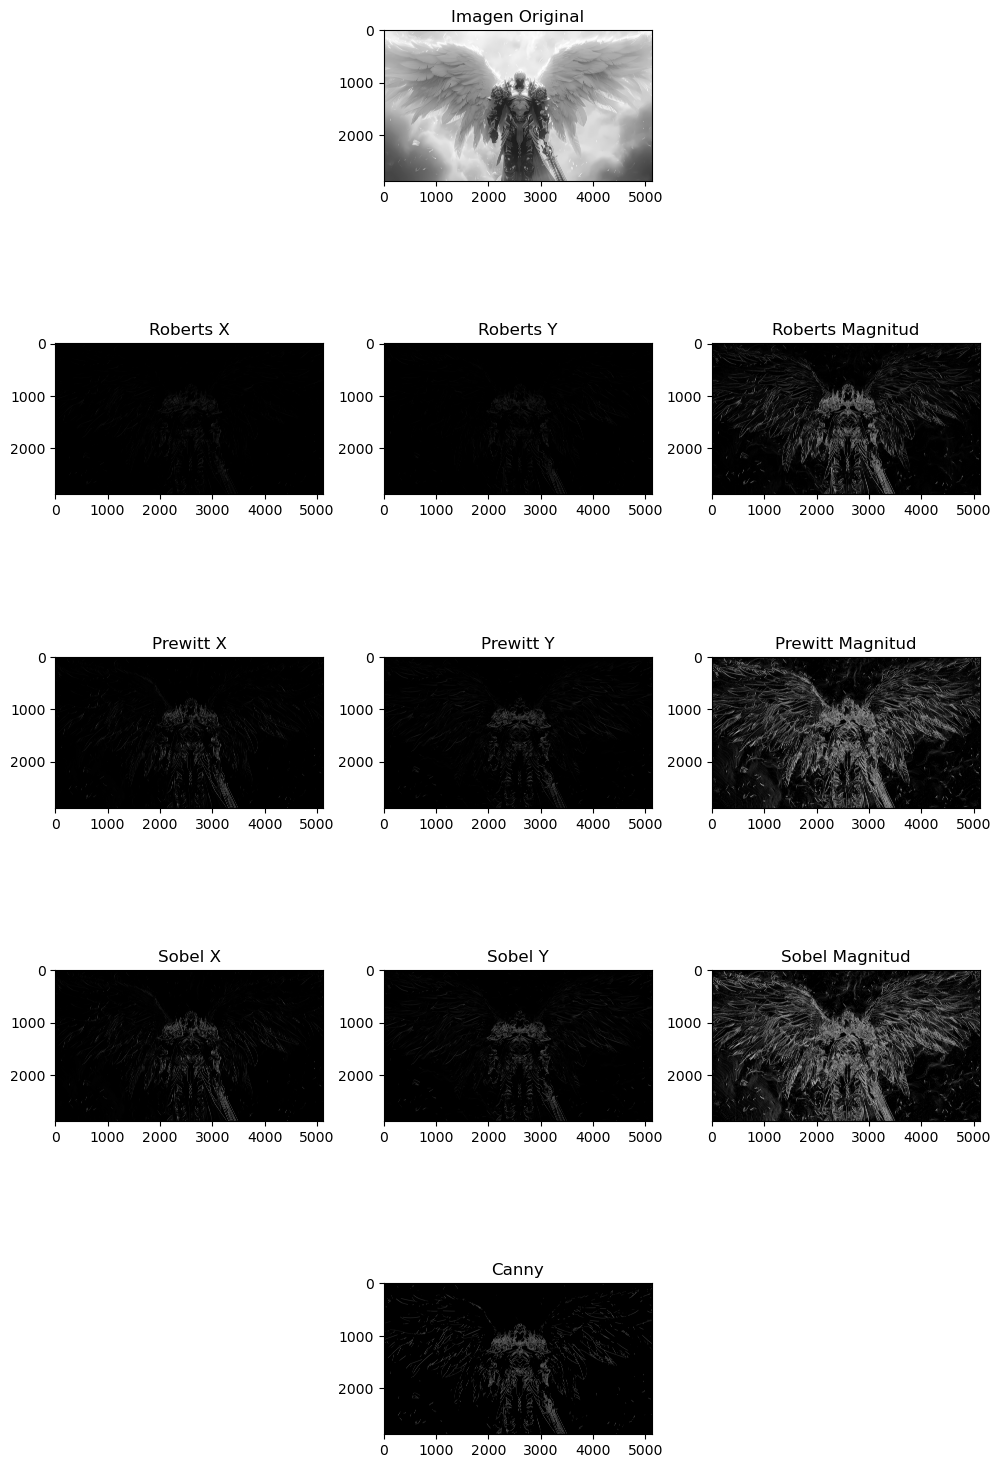

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Fond.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

roberts_x = np.array([[-1, 0], [0, 1]])
roberts_y = np.array([[0, -1], [1, 0]])

robx_img = cv2.filter2D(gray,-1,roberts_x)
roby_img = cv2.filter2D(gray,-1,roberts_y)

rob_grad = np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img)

#prewit

prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prex_img = cv2.filter2D(gray,-1,prewitt_x)
prey_img = cv2.filter2D(gray,-1,prewitt_y)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)

preww_dir = np.arctan2(prex_img, prey_img)


#sobel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobelx_img = cv2.filter2D(gray,-1,sobel_x)
sobely_img = cv2.filter2D(gray,-1,sobel_y)

sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir = np.arctan2(sobely_img, sobelx_img)

cany_img = cv2.Canny(gray, 100, 100)


plt.figure(figsize=(10, 16))


plt.subplot(5, 3, 2)
plt.imshow(gray, cmap='gray')
plt.title('Imagen Original')



plt.subplot(5, 3, 4)
plt.imshow(robx_img, cmap='gray')
plt.title('Roberts X')
plt.subplot(5, 3, 5)
plt.imshow(roby_img, cmap='gray')
plt.title('Roberts Y')
plt.subplot(5, 3, 6)
plt.imshow(rob_grad, cmap='gray')
plt.title('Roberts Magnitud')



plt.subplot(5, 3, 7)
plt.imshow(prex_img, cmap='gray')
plt.title('Prewitt X')
plt.subplot(5, 3, 8)
plt.imshow(prey_img, cmap='gray')
plt.title('Prewitt Y')
plt.subplot(5, 3, 9)
plt.imshow(prewitt_mag, cmap='gray')
plt.title('Prewitt Magnitud')



plt.subplot(5, 3, 10)
plt.imshow(sobelx_img, cmap='gray')
plt.title('Sobel X')
plt.subplot(5, 3, 11)
plt.imshow(sobely_img, cmap='gray')
plt.title('Sobel Y')
plt.subplot(5, 3, 12)
plt.imshow(sobel_mag, cmap='gray')
plt.title('Sobel Magnitud')



plt.subplot(5, 3, 14)
plt.imshow(cany_img, cmap='gray')
plt.title('Canny')

plt.tight_layout()
plt.show()








SOBEL

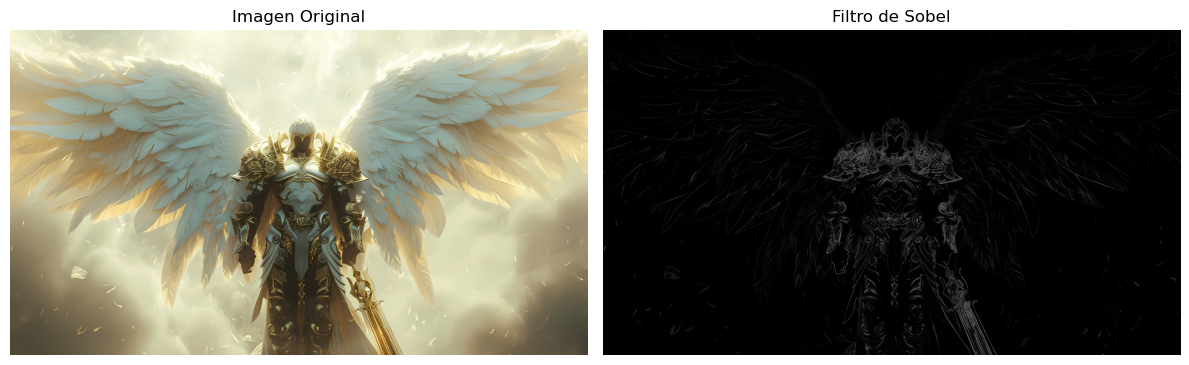

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    mag = np.sqrt(np.square(g_x) + np.square(g_y))

    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag


img = cv2.imread('Fond.jpg')
sobel_img = filtro_sobel(img)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(sobel_img, cmap='gray')
plt.title('Filtro de Sobel')
plt.tight_layout()
plt.show()



 


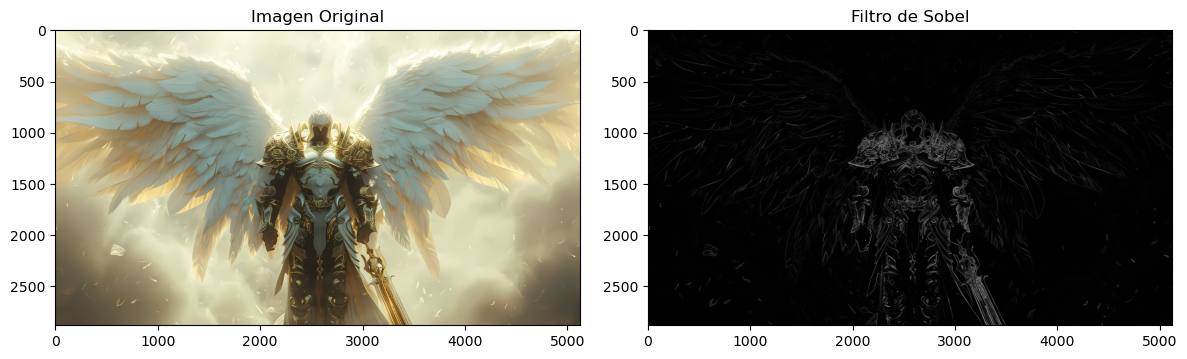

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img, kernel_size=3,umbral=100):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion flitro gauss
    img_gris = cv2.GaussianBlur(img_gris, (5, 5), 0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    #mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _,bordes = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    #OPERACION MORPH PARA UNIR BORDES ROTOS
    kernel_m = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return mag



img = cv2.imread('Fond.jpg')
sobel_img = filtro_sobel_mejorado(img)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(sobel_img, cmap='gray')
plt.title('Filtro de Sobel')

plt.tight_layout()
plt.show()



 


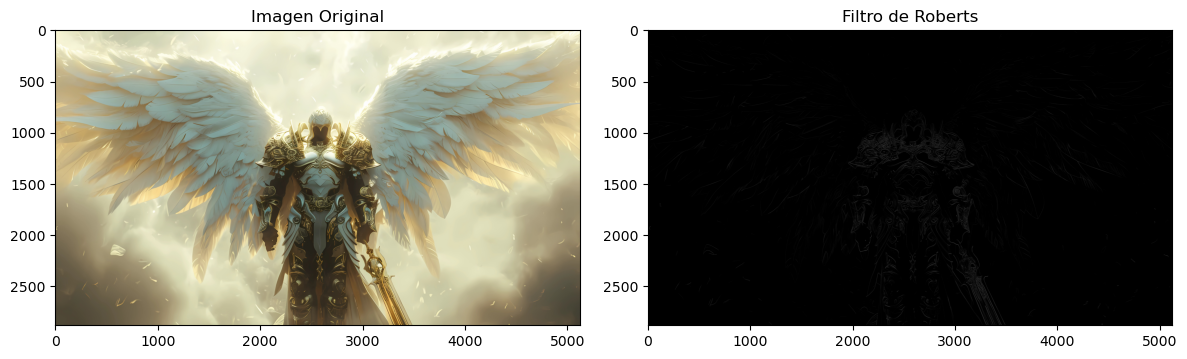

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtros_roberts(gray):
    img_gris = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)

    robertx = np.array([[-1, 0], [0, 1]],dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]],dtype=np.float32)

    r_x = cv2.filter2D(img_gris,-1,robertx)
    r_y = cv2.filter2D(img_gris,-1,roberty)

    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('Fond.jpg')
roberts_img = filtros_roberts(img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.subplot(1, 2, 2)
plt.imshow(roberts_img, cmap='gray')
plt.title('Filtro de Roberts')
plt.tight_layout()
plt.show()